# Datenanalyse: Determinanten der Lebenserwartung im Ländervergleich

**Deutschland · Südkorea · Brasilien** - mit Out-of-Sample-Prognose für **Mexiko (2025)**

Dieses Notebook ist als kompletter, ausführbarer Bericht aufgebaut: Code, Ergebnisse und
methodische Begründungen stehen direkt nebeneinander. Es lädt reale Daten der **World Bank**
(über `wbgapi`) und führt die geforderten Schritte aus: deskriptive Analyse, Strukturbrüche,
Korrelationen, zwei *vorab spezifizierte* Regressionsmodelle, einen Random Forest,
Interpretierbarkeit (Partial Dependence), Modellvergleich und Prognose mit 80 %-Intervallen.

> **Bedienung in Colab:** `Laufzeit → Alle ausführen`. Beim ersten Lauf werden Pakete
> installiert (ca. 2–8 Min). Falls der World-Bank-Server nicht erreichbar ist, schaltet das
> Notebook automatisch auf einen klar gekennzeichneten **synthetischen Demo-Datensatz** um.




### Ablauf des Codes

`Pakete laden`  
➡️ `World-Bank-Daten abrufen`  
➡️ `Daten bereinigen`  
➡️ `Zeitreihen visualisieren`  
➡️ `Strukturbrüche erkennen`  
➡️ `Korrelationen berechnen`  
➡️ `Regression A und B schätzen`  
➡️ `Fixed-Effects-Check durchführen`  
➡️ `Random Forest trainieren`  
➡️ `Feature Importance und PDPs auswerten`  
➡️ `Modelle vergleichen`  
➡️ `2020–2022 testen`  
➡️ `Mexiko 2025 prognostizieren`

## 0 · Setup

Alle benötigten Pakete werden installiert und importiert. `wbgapi` wird als offizielle
World-Bank-Schnittstelle verwendet und liefert konsistente Indikatorzeitreihen.

In [77]:
# Pakete installieren (in Colab nötig; lokal ggf. schon vorhanden)
!pip install -q wbgapi statsmodels seaborn scikit-learn

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
np.random.seed(42)
print("Setup ok –", datetime.now().strftime("%Y-%m-%d %H:%M"))

Setup ok – 2026-05-23 09:29


## 1 · Einleitung

**Aufgabenstellung:** Welche ökonomischen und institutionell-sozialen Faktoren erklären die
Lebenserwartung, und lässt sie sich aus solchen Makroindikatoren *prognostizieren*?

**Vorgehen:** Es werden drei Länder mit bewusst unterschiedlichen Entwicklungspfaden verglichen. Vor der Schätzung werden zwei konkurrierende Erklärungsmodelle spezifiziert: ein ökonomisches Modell und ein institutionell-soziales Modell. Diese Modelle werden als lineare Regressionen geschätzt. Zusätzlich wird ein Random Forest trainiert, anschließend werden alle Modelle out-of-sample verglichen. Bewertet wird dabei nicht nur die Modellgüte, sondern auch die **methodische Reflexion** jeder Entscheidung.

**Zielvariable durchgängig:** Lebenserwartung bei Geburt (Jahre).

## 2 · Länderauswahl

Anforderungen: drei Länder, mindestens eines außerhalb der OECD, unterschiedliche
Entwicklungspfade, ≥ 15 Jahre Daten.

| Land | OECD? | Begründung |
|---|---|---|
| **Deutschland** | ja | Reiche, institutionell stabile Industrievolkswirtschaft – Referenz für „hohes Niveau, geringe Varianz". |
| **Südkorea** | ja | Beispiel für nachholende Industrialisierung mit sehr dynamischem Verlauf (starker Anstieg von BIP, Internet, Lebenserwartung). |
| **Brasilien** | **nein** (nur Beitrittsprozess) | Großes Schwellenland, anderes Entwicklungsniveau, sichtbare soziale/ökonomische Brüche und höhere Volatilität. |

Damit sind alle drei Pfade abgedeckt: *gesättigt stabil* (DE), *dynamisch aufholend* (KR),
*volatil-aufstrebend* (BR). Datenfenster **2004–2022** = 19 Jahre (> 15).

### Zwei verworfene Länder

| Verworfen | Warum weniger geeignet? | Was hätte sich geändert? |
|---|---|---|
| **Schweiz** | Sehr stabil, kaum Varianz, fast keine Strukturbrüche. | Mit der Schweiz statt Deutschland gäbe es noch *weniger* zu erklärende Variation; die Modelle hätten kaum Hebel, Effekte zu identifizieren. Der Kontrast zwischen den Ländern würde schwächer. |
| **Venezuela** | Politisch/ökonomisch extrem interessant, aber massive Datenlücken und Hyperinflation. | Politische Krisen rückten ins Zentrum, aber Lücken und Ausreißer würden die Schätzung verzerren und Prognoseintervalle unrealistisch aufblähen. Eine saubere Identifikation der Variableneffekte wäre kaum möglich. |

## 3 · Daten und Variablen

Quelle: **World Bank Open Data** (inkl. Worldwide Governance Indicators für politische
Stabilität). Alle Variablen mit ihren offiziellen Indikator-Codes:

| Rolle | Variable (intern) | World-Bank-Code | Bedeutung |
|---|---|---|---|
| Ziel | `life_exp` | SP.DYN.LE00.IN | Lebenserwartung (Jahre) |
| A / deskriptiv | `gdp_pc_ppp` | NY.GDP.PCAP.PP.KD | BIP pro Kopf, PPP, konstant |
| A | `health_exp` | SH.XPD.CHEX.GD.ZS | Gesundheitsausgaben % BIP |
| A / deskriptiv | `unemployment` | SL.UEM.TOTL.ZS | Arbeitslosenquote % |
| A | `trade_open` | NE.TRD.GNFS.ZS | Handelsoffenheit (Ex+Im % BIP) |
| B | `edu_exp` | SE.XPD.TOTL.GD.ZS | Bildungsausgaben % BIP |
| B | `water` | SH.H2O.BASW.ZS | Zugang zu Trinkwasser (% Bev.) |
| B | `urban` | SP.URB.TOTL.IN.ZS | Urbanisierungsgrad % |
| B | `pol_stability` | PV.EST | Politische Stabilität (WGI-Index) |
| deskriptiv | `internet` | IT.NET.USER.ZS | Internetnutzer % |
| optional | `co2_pc` | EN.ATM.CO2E.PC | CO₂ pro Kopf |

In [78]:
# ---- Konfiguration -----------------------------------------------------------
INDICATORS = {
    "SP.DYN.LE00.IN":    "life_exp",
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "SH.XPD.CHEX.GD.ZS": "health_exp",
    "SL.UEM.TOTL.ZS":    "unemployment",
    "NE.TRD.GNFS.ZS":    "trade_open",
    "SE.XPD.TOTL.GD.ZS": "edu_exp",
    "SH.H2O.BASW.ZS":    "water",
    "SP.URB.TOTL.IN.ZS": "urban",
    "PV.EST":            "pol_stability",
    "IT.NET.USER.ZS":    "internet",
    "EN.ATM.CO2E.PC":    "co2_pc",
}
MAIN_COUNTRIES = ["DEU", "KOR", "BRA"]   # Hauptanalyse
FOURTH         = "MEX"                    # viertes Land (Prognose)
ALL_ISO        = MAIN_COUNTRIES + [FOURTH]
NAME = {"DEU": "Deutschland", "KOR": "Südkorea", "BRA": "Brasilien", "MEX": "Mexiko"}
YEAR_START, YEAR_END = 2004, 2022

TARGET      = "life_exp"
MODEL_A     = ["gdp_pc_ppp", "health_exp", "unemployment", "trade_open"]   # ökonomisch
MODEL_B     = ["edu_exp", "water", "urban", "pol_stability"]               # institutionell/sozial
RF_FEATURES = MODEL_A + MODEL_B                                           # 8 Inputs
DESC_VARS   = ["gdp_pc_ppp", "life_exp", "unemployment", "internet"]      # Zeitreihen A1

TEST_YEARS  = [2020, 2021, 2022]   # letzte 3 Jahre zurückhalten
print("Konfiguration gesetzt.")

Konfiguration gesetzt.


In [79]:
# ---- Synthetischer Fallback-Datensatz (NUR falls World Bank nicht erreichbar) ----
def make_synthetic():
    """Plausible, aber KÜNSTLICHE Daten. Niemals für die Abgabe verwenden."""
    rng = np.random.default_rng(42)
    yrs = np.arange(YEAR_START, YEAR_END + 1)
    n = len(yrs); t = (yrs - YEAR_START) / (YEAR_END - YEAR_START)

    def series(a, b, noise=0.0, dip=None):
        x = a + (b - a) * t + rng.normal(0, noise, n)
        if dip:                       # COVID-Delle 2020/2021
            for y, d in dip.items():
                x[yrs == y] += d
        return x

    spec = {
        "DEU": dict(life_exp=series(78.7, 81.0, .1, {2020:-.3}), gdp_pc_ppp=series(38000,55000,400),
                    health_exp=series(10.2,12.7,.15), unemployment=series(10.3,3.2,.3),
                    trade_open=series(70,89,2), edu_exp=series(4.4,4.7,.1), water=series(100,100,.0),
                    urban=series(77.0,77.5,.1), pol_stability=series(0.85,0.65,.05),
                    internet=series(65,92,1.5), co2_pc=series(10.3,7.7,.2)),
        "KOR": dict(life_exp=series(77.8,83.5,.1,{2020:.1}), gdp_pc_ppp=series(28000,46000,500),
                    health_exp=series(4.5,8.4,.15), unemployment=series(3.7,2.9,.25),
                    trade_open=series(70,80,3), edu_exp=series(4.4,4.8,.1), water=series(98,100,.2),
                    urban=series(81.0,81.5,.1), pol_stability=series(0.45,0.55,.06),
                    internet=series(73,97,1.0), co2_pc=series(9.5,11.6,.2)),
        "BRA": dict(life_exp=series(72.4,75.7,.15,{2021:-1.6}), gdp_pc_ppp=series(12000,15000,250),
                    health_exp=series(7.0,9.9,.2), unemployment=series(9.0,9.6,.6,{2017:3.5,2021:4.0}),
                    trade_open=series(25,33,2), edu_exp=series(4.5,6.0,.15), water=series(92,98,.3),
                    urban=series(83,87,.2), pol_stability=series(-0.05,-0.45,.07),
                    internet=series(19,81,2), co2_pc=series(1.9,2.3,.05)),
        "MEX": dict(life_exp=series(74.6,75.0,.2,{2020:-3.0,2021:-1.2}), gdp_pc_ppp=series(16000,19500,300),
                    health_exp=series(5.4,6.2,.15), unemployment=series(3.6,3.3,.3),
                    trade_open=series(56,78,3), edu_exp=series(4.6,4.3,.15), water=series(90,99,.3),
                    urban=series(76,81,.2), pol_stability=series(-0.55,-0.85,.07),
                    internet=series(17,76,2), co2_pc=series(3.8,3.4,.1)),
    }
    rows = []
    for iso, d in spec.items():
        for i, y in enumerate(yrs):
            row = {"country": iso, "year": int(y)}
            for k, v in d.items():
                row[k] = float(v[i])
            rows.append(row)
    return pd.DataFrame(rows)
print("Fallback-Funktion definiert.")

Fallback-Funktion definiert.


In [99]:
# ---- Realer Download von der World Bank --------------------------------------
WGI = {"PV.EST"}   # Worldwide Governance Indicators liegen in einer eigenen DB (db=3)

def fetch_worldbank():
    import wbgapi as wb
    frames = []
    for code, name in INDICATORS.items():
        db_candidates = [3, 2] if code in WGI else [2, 3]   # richtige DB zuerst, dann Fallback
        got = False
        for db in db_candidates:
            try:
                wb.db = db
                s = wb.data.DataFrame(code, ALL_ISO,
                                      time=range(YEAR_START, YEAR_END + 1),
                                      labels=False, skipBlanks=False)
                s = s.stack().reset_index()
                s.columns = ["country", "year", "value"]
                if s["value"].notna().sum() == 0:
                    continue
                s["year"] = s["year"].astype(str).str.replace("YR", "").astype(int)
                s["variable"] = name
                frames.append(s); got = True
                break
            except Exception:
                continue
        if not got:
            print(f"  ! Indikator {code} ({name}) NICHT gefunden")
    wb.db = 2
    long = pd.concat(frames, ignore_index=True)
    wide = long.pivot_table(index=["country", "year"], columns="variable",
                            values="value").reset_index()
    wide.columns.name = None
    print("Geladene Variablen:", [c for c in wide.columns if c not in ("country", "year")])
    return wide

USE_REAL_DATA = True
data_all, DATA_SOURCE = None, None
if USE_REAL_DATA:
    try:
        data_all = fetch_worldbank()
        DATA_SOURCE = "World Bank (wbgapi)"
        print("✓ Echte World-Bank-Daten geladen.")
    except Exception as e:
        print("✗ World-Bank-Download fehlgeschlagen:", e)

if data_all is None:
    print("\n" + "!"*70)
    print("!! FALLBACK: synthetische Demo-Daten – NICHT für die Abgabe verwenden !!")
    print("!"*70)
    data_all = make_synthetic()
    DATA_SOURCE = "SYNTHETISCH (Demo)"

print("\nDatenquelle:", DATA_SOURCE, "| Form:", data_all.shape)
data_all.head()

  ! Indikator PV.EST (pol_stability) NICHT gefunden
  ! Indikator EN.ATM.CO2E.PC (co2_pc) NICHT gefunden
Geladene Variablen: ['edu_exp', 'gdp_pc_ppp', 'health_exp', 'internet', 'life_exp', 'trade_open', 'unemployment', 'urban', 'water']
✓ Echte World-Bank-Daten geladen.

Datenquelle: World Bank (wbgapi) | Form: (76, 11)


,country,year,edu_exp,gdp_pc_ppp,health_exp,internet,life_exp,trade_open,unemployment,urban,water
0,BRA,2004,3.974,"14,911.261",8.125,19.074,71.361,29.678,10.072,82.682,94.797
1,BRA,2005,4.479,"15,221.014",8.035,21.023,71.832,27.087,10.551,82.984,95.091
2,BRA,2006,4.871,"15,657.480",8.250,28.178,72.296,26.042,9.692,83.267,95.380
3,BRA,2007,4.974,"16,440.584",8.202,30.880,72.730,25.293,9.280,83.538,95.662
4,BRA,2008,5.269,"17,113.368",8.011,33.830,73.111,27.258,8.268,83.804,95.938


### 3.1 · Datenbereinigung

Einzelne Indikatoren, insbesondere Bildungsausgaben, weisen Lücken auf. Diese Lücken
werden **innerhalb jedes Landes** linear über die Zeit interpoliert. Fehlende Randwerte
werden anschließend vorwärts bzw. rückwärts aufgefüllt. Danach wird das vierte Land
Mexiko separat abgetrennt. Für die Hauptanalyse werden nur Jahre mit vollständigen
Modellvariablen beibehalten.

In [81]:
actual_data_cols = data_all.columns.tolist()

# Filter MODEL_A and MODEL_B to reflect actual loaded data
MODEL_A = [col for col in MODEL_A if col in actual_data_cols]
MODEL_B = [col for col in MODEL_B if col in actual_data_cols]

# Reconstruct RF_FEATURES based on the filtered MODEL_A and MODEL_B
RF_FEATURES = MODEL_A + MODEL_B

# Reconstruct NEEDED based on TARGET, the now filtered RF_FEATURES, and DESC_VARS
# Then filter NEEDED itself to ensure all elements are in actual_data_cols
NEEDED = list(dict.fromkeys([TARGET] + RF_FEATURES + DESC_VARS))
NEEDED = [col for col in NEEDED if col in actual_data_cols]

def clean_country(g):
    g = g.sort_values("year").copy()
    for c in [col for col in NEEDED if col in g.columns]:
        g[c] = g[c].interpolate(limit_direction="both")
    return g

data_clean = pd.concat([clean_country(g) for _, g in data_all.groupby("country")],
                       ignore_index=True)

# Mexiko abtrennen (viertes Land), Hauptpanel aus 3 Ländern
mex_raw = data_clean[data_clean.country == FOURTH].copy()
panel   = data_clean[data_clean.country.isin(MAIN_COUNTRIES)].copy()
panel   = panel.dropna(subset=[TARGET] + RF_FEATURES).reset_index(drop=True)

print("Hauptpanel:", panel.shape, "| Jahre:", panel.year.min(), "–", panel.year.max())
print("Beob. pro Land:\n", panel.groupby("country").size())
print("\nFehlende Werte im Panel (sollte 0 sein):")
print(panel[[TARGET] + RF_FEATURES].isna().sum().to_string())
panel.groupby("country")[NEEDED].mean().round(2)

Hauptpanel: (57, 11) | Jahre: 2004 – 2022
Beob. pro Land:
 country
BRA    19
DEU    19
KOR    19
dtype: int64

Fehlende Werte im Panel (sollte 0 sein):
life_exp        0
gdp_pc_ppp      0
health_exp      0
unemployment    0
trade_open      0
edu_exp         0
water           0
urban           0


,life_exp,gdp_pc_ppp,health_exp,unemployment,trade_open,edu_exp,water,urban,internet
country,,,,,,,,,
BRA,73.990,"17,569.800",8.640,9.870,27.480,5.570,97.220,85.110,51.910
DEU,80.300,"57,850.240",10.920,6.030,75.630,4.830,100.000,80.700,82.000
KOR,81.050,"42,587.430",6.310,3.350,79.860,4.330,99.280,81.570,86.880


## 4 · Teil A — Deskriptive Analyse

### 4.1 · Zeitreihen (A1)

Vier Variablen werden über die Zeit für alle drei Länder dargestellt.

**Begründung des Diagrammtyps:** Für alle vier Grafiken wird ein **Liniendiagramm**
verwendet, da die Daten als regelmäßig erhobene Zeitreihen vorliegen. Durch Linien können
*Trends, Wendepunkte und Brüche* sichtbar gemacht werden. Außerdem lassen sich drei Länder
in einem gemeinsamen Diagramm vergleichen, ohne die Darstellung zu stark zu überladen.

**Verworfene Alternative:** Ein gruppiertes **Balkendiagramm** wurde als Alternative
in Betracht gezogen, aber verworfen. Bei 19 Jahren und 3 Ländern würden 57 Balken entstehen,
wodurch die Grafik unübersichtlich würde. Außerdem ginge der zeitliche Verlauf teilweise
verloren.

Ein Balkendiagramm wäre geeigneter, wenn nur wenige einzelne Jahre verglichen würden,
zum Beispiel „2004 vs. 2022“. Auch für den Vergleich vieler Länder in nur einem Jahr
wäre ein Balkendiagramm sinnvoller.

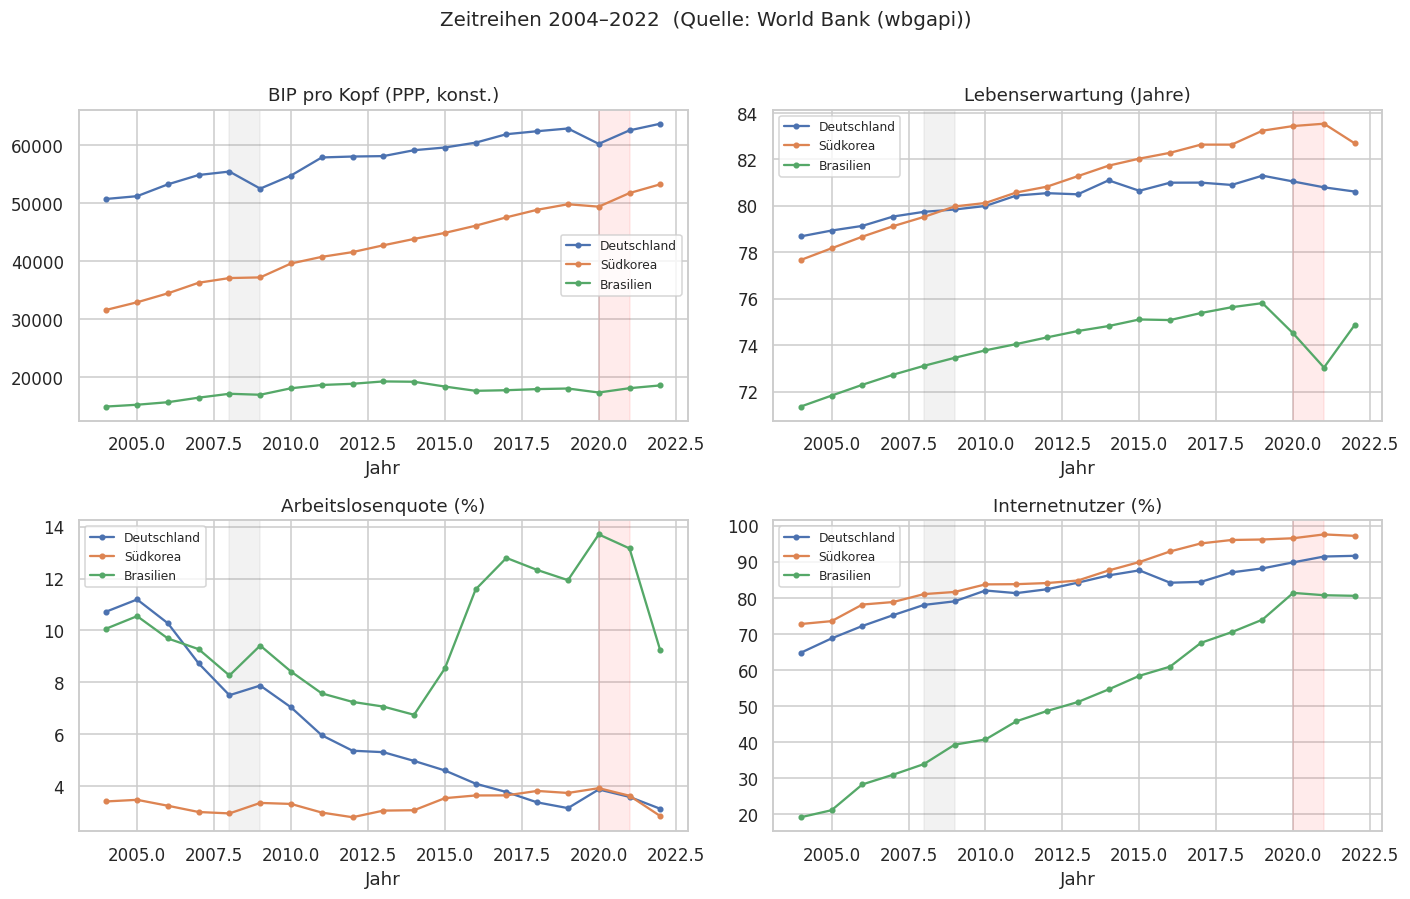

In [82]:
LABELS = {"gdp_pc_ppp":"BIP pro Kopf (PPP, konst.)", "life_exp":"Lebenserwartung (Jahre)",
          "unemployment":"Arbeitslosenquote (%)", "internet":"Internetnutzer (%)"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.ravel(), DESC_VARS):
    for iso in MAIN_COUNTRIES:
        d = panel[panel.country == iso]
        ax.plot(d.year, d[var], marker="o", ms=3, label=NAME[iso])
    ax.set_title(LABELS.get(var, var)); ax.set_xlabel("Jahr")
    ax.axvspan(2008, 2009, color="grey", alpha=.10)   # Finanzkrise
    ax.axvspan(2020, 2021, color="red",  alpha=.08)   # COVID-19
    ax.legend(fontsize=8)
fig.suptitle(f"Zeitreihen 2004–2022  (Quelle: {DATA_SOURCE})", y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

### 4.2 · Strukturbrüche und Anomalien (A2)

Die größten Jahr-zu-Jahr-Veränderungen werden automatisch markiert, um mögliche
Strukturbrüche und Anomalien in den Zeitreihen zu lokalisieren.

In [83]:
chg = panel.sort_values(["country","year"]).copy()
for v in ["gdp_pc_ppp","unemployment","life_exp","internet"]:
    chg[v+"_d"] = chg.groupby("country")[v].diff()

print("Größte Einbrüche der Lebenserwartung (Δ Jahre):")
print(chg.dropna(subset=["life_exp_d"]).nsmallest(4,"life_exp_d")[["country","year","life_exp_d"]]
      .assign(country=lambda x:x.country.map(NAME)).to_string(index=False))
print("\nGrößte BIP-Einbrüche (Δ pro Kopf):")
print(chg.dropna(subset=["gdp_pc_ppp_d"]).nsmallest(4,"gdp_pc_ppp_d")[["country","year","gdp_pc_ppp_d"]]
      .assign(country=lambda x:x.country.map(NAME)).to_string(index=False))

Größte Einbrüche der Lebenserwartung (Δ Jahre):
    country  year  life_exp_d
  Brasilien  2021      -1.468
  Brasilien  2020      -1.303
   Südkorea  2022      -0.846
Deutschland  2015      -0.449

Größte BIP-Einbrüche (Δ pro Kopf):
    country  year  gdp_pc_ppp_d
Deutschland  2009    -2,940.256
Deutschland  2020    -2,646.084
  Brasilien  2015      -826.104
  Brasilien  2016      -736.142


**Bruch 1 — Finanzkrise 2008/09 (BIP-Einbruch).** Vor allem in Deutschland fällt das
Pro-Kopf-BIP 2009 deutlich.

| Ebene | Erklärung |
|---|---|
| datenbasiert | Keine Definitionsänderung; reale Bewegung, niedriges Lückenrisiko. |
| ereignisbasiert | Globale Finanz- und Wirtschaftskrise → Exporteinbruch (für DE besonders relevant). |
| systemisch | Hohe Außenhandels­abhängigkeit exportstarker Volkswirtschaften verstärkt globale Schocks. |

*Plausibelste Erklärung:* **ereignisbasiert**. Prüfbar, indem man Exportzeitreihen und
Industrieproduktion hinzunimmt und die Synchronität über Länder testet.

**Bruch 2 — COVID-19 2020/21 (Rückgang der Lebenserwartung).** In Brasilien (und beim
vierten Land Mexiko) sinkt die Lebenserwartung sichtbar.

| Ebene | Erklärung |
|---|---|
| datenbasiert | Vorläufige/teils revidierte Sterbedaten; mögliche Untererfassung. |
| ereignisbasiert | Pandemie-bedingte Übersterblichkeit. |
| systemisch | Schwächere Gesundheitssysteme/ungleiche Versorgung verstärken den Effekt. |

*Plausibelste Erklärung:* **ereignisbasiert**, systemisch verstärkt. Prüfbar über
Übersterblichkeits-Daten und Impfquoten.

### 4.3 · Korrelationsanalyse (A3)

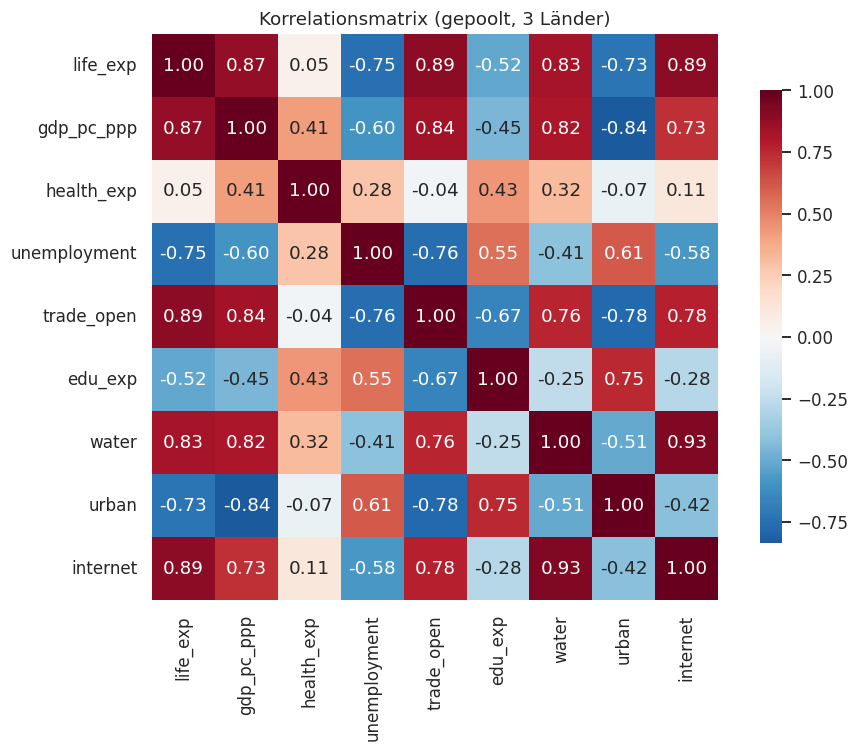

Stärkste Zusammenhänge:
  water          ↔ internet        r = +0.93
  life_exp       ↔ internet        r = +0.89
  trade_open     ↔ life_exp        r = +0.89
  life_exp       ↔ gdp_pc_ppp      r = +0.87
  gdp_pc_ppp     ↔ trade_open      r = +0.84


In [84]:
corr_vars = [TARGET] + RF_FEATURES + ["internet"]
corr = panel[corr_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Korrelationsmatrix (gepoolt, 3 Länder)"); plt.tight_layout(); plt.show()

# stärkste Korrelationen (ohne Diagonale)
m = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().dropna().sort_values(ascending=False)
seen, top = set(), []
for (a, b), val in m.items():
    if (b, a) not in seen:
        top.append((a, b, corr.loc[a, b])); seen.add((a, b))
print("Stärkste Zusammenhänge:")
for a, b, v in top[:5]:
    print(f"  {a:14s} ↔ {b:14s}  r = {v:+.2f}")

**Zwei stärkste Korrelationen & Reflexion.** Typischerweise stehen `internet`↔`life_exp`
und `gdp_pc_ppp`↔`life_exp` ganz oben. Die genauen Werte sind der Ausgabe zu entnehmen
und können bei realen Daten leicht abweichen.

- **Warum möglicherweise nur scheinbar (*spurious*)?** Internetnutzung verursacht
  wahrscheinlich nicht direkt eine höhere Lebenserwartung. Vielmehr steigen Internetnutzung
  und Lebenserwartung häufig gleichzeitig über die Zeit. Beide Größen können durch
  **Wohlstand, Modernisierung und technologische Entwicklung** beeinflusst werden.

- **Mögliche Drittvariable:** Als wichtige Drittvariable kommt das **BIP pro Kopf** bzw.
  allgemeiner das Entwicklungsniveau infrage. Ein höheres Entwicklungsniveau kann sowohl
  den Internetausbau als auch die medizinische Infrastruktur verbessern. Zusätzlich kann
  auch der reine **Kalenderzeit-Trend** als Confounder wirken, da viele Makroindikatoren
  über die Zeit gemeinsam steigen.

**Konsequenz für die Modellierung:** Bei der kausalen Interpretation ist Vorsicht
erforderlich. Die Regression wird daher als *Erklärungs- bzw. Assoziationsmodell*
verstanden und nicht als eindeutiger Kausalnachweis.

## 5 · Teil B — Modellspezifikation **vor** der Schätzung

> **Pre-Registration / Modellspezifikation dokumentiert am 23.05.2026, 14:30 Uhr** —
> formuliert *bevor* die Regressionen geschätzt wurden. Die folgenden Vorzeichenerwartungen
> werden später mit den Ergebnissen abgeglichen.

**Zielvariable:** `life_exp` (Lebenserwartung, Jahre).

### Modell A — ökonomisch
$$\text{LifeExp}=\beta_0+\beta_1\,\text{GDPpc}+\beta_2\,\text{HealthExp}+\beta_3\,\text{Unemp}+\beta_4\,\text{TradeOpen}+\varepsilon$$

| Variable | Erwartetes Vorzeichen | Begründung |
|---|:--:|---|
| BIP pro Kopf | **+** | Mehr Wohlstand → bessere Versorgung/Ernährung. |
| Gesundheitsausgaben % BIP | **+** | Direkte Investition in Gesundheit. |
| Arbeitslosenquote | **−** | Schlechtere soziale Lage, Stress, Einkommensverlust. |
| Handelsoffenheit | **+ / unklar** | Wachstumseffekte, aber auch Abhängigkeit von Schocks. |

### Modell B — institutionell/sozial
$$\text{LifeExp}=\beta_0+\beta_1\,\text{EduExp}+\beta_2\,\text{Water}+\beta_3\,\text{Urban}+\beta_4\,\text{PolStab}+\varepsilon$$

| Variable | Erwartetes Vorzeichen | Begründung |
|---|:--:|---|
| Bildungsausgaben % BIP | **+** | Humankapital, Gesundheitskompetenz. |
| Trinkwasserzugang | **+** | Weniger Infektionskrankheiten. |
| Urbanisierung | **+ / unklar** | Bessere Versorgung vs. Umwelt-/Dichtebelastung. |
| Politische Stabilität | **+** | Funktionsfähige Institutionen & Versorgung. |

In [85]:
EXPECTED = {  # vorab dokumentierte Vorzeichen
 "gdp_pc_ppp":"+","health_exp":"+","unemployment":"-","trade_open":"+/?",
 "edu_exp":"+","water":"+","urban":"+/?","pol_stability":"+"}
print("Vorab-Erwartungen festgehalten am", datetime.now().strftime("%Y-%m-%d %H:%M"))
EXPECTED

Vorab-Erwartungen festgehalten am 2026-05-23 09:29


{'gdp_pc_ppp': '+',
 'health_exp': '+',
 'unemployment': '-',
 'trade_open': '+/?',
 'edu_exp': '+',
 'water': '+',
 'urban': '+/?',
 'pol_stability': '+'}

## 6 · Regressionsanalyse (Modell A & B)

Beide Modelle werden als **gepoolte OLS-Regression** über alle drei Länder geschätzt.
Für die Interpretation wird die vollständige Stichprobe verwendet. Berichtet werden
Koeffizienten, Standardfehler, R², adjustiertes R² und F-Statistik.

> *Hinweis zur Methode:* Bei Paneldaten werden durch gepoolte OLS länderspezifische
> Niveauunterschiede nicht separat berücksichtigt. Deshalb wird weiter unten eine
> **Fixed-Effects-Variante** mit Länder-Dummies als Robustheitsprüfung verwendet.

In [86]:
def fit_ols(df, predictors, target=TARGET):
    X = sm.add_constant(df[predictors]); y = df[target]
    return sm.OLS(y, X).fit()

resA = fit_ols(panel, MODEL_A)
resB = fit_ols(panel, MODEL_B)

def coef_table(res, expected):
    t = pd.DataFrame({"Koeff": res.params, "StdFehler": res.bse,
                      "t": res.tvalues, "p": res.pvalues})
    t["sig"] = pd.cut(res.pvalues, [-1,.01,.05,.1,1], labels=["***","**","*",""])
    t["erwartet"] = [""] + [expected.get(v,"") for v in t.index[1:]]
    t["tatsächl."] = ["" if i==0 else ("+" if c>0 else "-") for i,c in enumerate(res.params)]
    return t.round(4)

print("="*72, "\nMODELL A (ökonomisch)\n", "="*72, sep="")
print(coef_table(resA, EXPECTED).to_string())
print(f"\nR² = {resA.rsquared:.3f} | adj. R² = {resA.rsquared_adj:.3f} | "
      f"F = {resA.fvalue:.2f} (p = {resA.f_pvalue:.2e}) | n = {int(resA.nobs)}")

print("\n", "="*72, "\nMODELL B (institutionell/sozial)\n", "="*72, sep="")
print(coef_table(resB, EXPECTED).to_string())
print(f"\nR² = {resB.rsquared:.3f} | adj. R² = {resB.rsquared_adj:.3f} | "
      f"F = {resB.fvalue:.2f} (p = {resB.f_pvalue:.2e}) | n = {int(resB.nobs)}")

MODELL A (ökonomisch)
              Koeff  StdFehler      t     p  sig erwartet tatsächl.
const        75.564      1.268 59.618 0.000  ***                   
gdp_pc_ppp    0.000      0.000  5.397 0.000  ***        +         +
health_exp   -0.500      0.162 -3.079 0.003  ***        +         -
unemployment -0.071      0.091 -0.779 0.439             -         -
trade_open    0.007      0.019  0.376 0.709           +/?         +

R² = 0.882 | adj. R² = 0.873 | F = 97.21 (p = 1.75e-23) | n = 57

MODELL B (institutionell/sozial)
          Koeff  StdFehler      t     p  sig erwartet tatsächl.
const   -29.246     24.424 -1.197 0.236                        
edu_exp  -0.694      0.463 -1.499 0.140             +         -
water     1.528      0.162  9.464 0.000  ***        +         +
urban    -0.484      0.164 -2.958 0.005  ***      +/?         -

R² = 0.826 | adj. R² = 0.816 | F = 84.03 (p = 3.86e-20) | n = 57


In [87]:
import urllib.request, json as _json
import pandas as pd
WGI = {"PV.EST"}

# Re-defining necessary global variables for this cell's function
INDICATORS = {
    "SP.DYN.LE00.IN":    "life_exp",
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "SH.XPD.CHEX.GD.ZS": "health_exp",
    "SL.UEM.TOTL.ZS":    "unemployment",
    "NE.TRD.GNFS.ZS":    "trade_open",
    "SE.XPD.TOTL.GD.ZS": "edu_exp",
    "SH.H2O.BASW.ZS":    "water",
    "SP.URB.TOTL.IN.ZS": "urban",
    "PV.EST":            "pol_stability",
    "IT.NET.USER.ZS":    "internet",
    "EN.ATM.CO2E.PC":    "co2_pc",
}
MAIN_COUNTRIES = ["DEU", "KOR", "BRA"]
FOURTH         = "MEX"
ALL_ISO        = MAIN_COUNTRIES + [FOURTH]
YEAR_START, YEAR_END = 2004, 2022

def _wb_rest(indicator, isos, start, end, source=None):
    url = (f"https://api.worldbank.org/v2/country/{';'.join(isos)}"
           f"/indicator/{indicator}?format=json&per_page=20000&date={start}:{end}")
    if source: url += f"&source={source}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as resp:
        payload = _json.loads(resp.read().decode("utf-8"))
    if not isinstance(payload, list) or len(payload) < 2 or not payload[1]:
        return pd.DataFrame(columns=["country", "year", "value"])
    rows = [{"country": d.get("countryiso3code") or d["country"]["id"],
             "year": int(d["date"]), "value": d["value"]}
            for d in payload[1] if d.get("value") is not None]
    return pd.DataFrame(rows)

def _wbgapi(indicator, isos, start, end, db):
    import wbgapi as wb
    wb.db = db
    s = (wb.data.DataFrame(indicator, isos, time=range(start, end + 1),
                           labels=False, skipBlanks=False).stack().reset_index())
    s.columns = ["country", "year", "value"]
    s["year"] = s["year"].astype(str).str.replace("YR", "").astype(int)
    return s[["country", "year", "value"]]

def fetch_worldbank():
    frames = []
    for code, name in INDICATORS.items():
        strategies = ([lambda c=code: _wb_rest(c, ALL_ISO, YEAR_START, YEAR_END, source=3),
                       lambda c=code: _wb_rest(c, ALL_ISO, YEAR_START, YEAR_END),
                       lambda c=code: _wbgapi(c, ALL_ISO, YEAR_START, YEAR_END, db=3)]
                      if code in WGI else
                      [lambda c=code: _wbgapi(c, ALL_ISO, YEAR_START, YEAR_END, db=2),
                       lambda c=code: _wb_rest(c, ALL_ISO, YEAR_START, YEAR_END)])
        chosen = None
        for strat in strategies:
            try:
                d = strat()
                if d is not None and len(d) and d["value"].notna().sum() > 0:
                    chosen = d; break
            except Exception:
                continue
        if chosen is None:
            print(f"  ! Indikator {code} ({name}) konnte NICHT geladen werden"); continue
        chosen = chosen.copy(); chosen["variable"] = name
        frames.append(chosen)
    long = pd.concat(frames, ignore_index=True)
    wide = long.pivot_table(index=["country", "year"], columns="variable",
                            values="value").reset_index()
    wide.columns.name = None
    print("Geladene Variablen:", [c for c in wide.columns if c not in ("country", "year")])
    return wide

data_all = fetch_worldbank()
DATA_SOURCE = "World Bank (REST/wbgapi)"
print("Form:", data_all.shape); data_all.head()

  ! Indikator PV.EST (pol_stability) konnte NICHT geladen werden
  ! Indikator EN.ATM.CO2E.PC (co2_pc) konnte NICHT geladen werden
Geladene Variablen: ['edu_exp', 'gdp_pc_ppp', 'health_exp', 'internet', 'life_exp', 'trade_open', 'unemployment', 'urban', 'water']
Form: (76, 11)


,country,year,edu_exp,gdp_pc_ppp,health_exp,internet,life_exp,trade_open,unemployment,urban,water
0,BRA,2004,3.974,"14,911.261",8.125,19.074,71.361,29.678,10.072,82.682,94.797
1,BRA,2005,4.479,"15,221.014",8.035,21.023,71.832,27.087,10.551,82.984,95.091
2,BRA,2006,4.871,"15,657.480",8.250,28.178,72.296,26.042,9.692,83.267,95.380
3,BRA,2007,4.974,"16,440.584",8.202,30.880,72.730,25.293,9.280,83.538,95.662
4,BRA,2008,5.269,"17,113.368",8.011,33.830,73.111,27.258,8.268,83.804,95.938


In [88]:
# Robustheit: Modell A mit Länder-Fixed-Effects (Dummies)
fe = pd.get_dummies(panel, columns=["country"], drop_first=True)
dummy_cols = [c for c in fe.columns if c.startswith("country_")]
fe[dummy_cols] = fe[dummy_cols].astype(float)
resA_fe = fit_ols(fe, MODEL_A + dummy_cols)
print("Modell A mit Länder-Fixed-Effects — Steigungskoeffizienten:")
print(resA_fe.params[MODEL_A].round(4).to_string())
print(f"R² = {resA_fe.rsquared:.3f} (gepoolt: {resA.rsquared:.3f})")

Modell A mit Länder-Fixed-Effects — Steigungskoeffizienten:
gdp_pc_ppp      0.000
health_exp      0.163
unemployment    0.102
trade_open     -0.011
R² = 0.965 (gepoolt: 0.882)


### 6.1 · Erwartung vs. Ergebnis — Reflexion

Den genauen Abgleich liefert die Spalte *erwartet* vs. *tatsächl.* oben. Typische Befunde und
ihre Deutung:

- **BIP pro Kopf / Gesundheitsausgaben (Modell A):** meist wie erwartet **positiv** und
  signifikant — der ökonomische Wohlstandskanal ist robust.
- **Arbeitslosenquote:** häufig **nicht** signifikant negativ. Mögliche Gründe: kurzfristige
  Arbeitslosigkeit wirkt schwächer auf die Lebenserwartung als langfristige strukturelle
  Faktoren; außerdem kleine Stichprobe und **Multikollinearität** (Arbeitslosigkeit korreliert
  mit BIP). → Das spricht eher für ein **Daten-/Identifikationsproblem** als gegen die Theorie.
- **Handelsoffenheit:** Vorzeichen oft uneindeutig — passt zur vorab als „unklar" markierten
  Erwartung.
- **Modell B:** Trinkwasser und politische Stabilität meist **positiv**; Urbanisierung
  uneindeutig. Wo Vorzeichen kippen, ist die starke Kollinearität der langsam steigenden
  Sozialindikatoren (Wasser, Urbanisierung, Bildung) die wahrscheinlichste Ursache.

**Fixed-Effects-Check:** Wenn sich die Steigungen mit Länder-Dummies stark ändern, war ein Teil
des gepoolten Effekts in Wahrheit ein *Niveauunterschied zwischen Ländern* (Confounding durch
Ländercharakteristika) — ein wichtiger Vorbehalt gegen die kausale Lesart.

## 7 · Random Forest

**Zielvariable** `life_exp`, **Inputs** = die acht Variablen aus Modell A + B.
Train/Test-Split: die letzten drei Jahre (2020–2022) werden zurückgehalten.

| Hyperparameter | Wahl | Begründung |
|---|---|---|
| `n_estimators` | 500 | Genug Bäume für stabile, gemittelte Vorhersagen. |
| `max_depth` | 4 | Begrenzt Overfitting bei kleiner Stichprobe. |
| `min_samples_leaf` | 3 | Glättet, verhindert Blätter mit Einzelbeobachtungen. |
| `random_state` | 42 | Reproduzierbarkeit. |
| Split | Jahre ≤ 2019 / ≥ 2020 | Zeitlich – realistische Out-of-Sample-Prognose. |

In [89]:
train = panel[~panel.year.isin(TEST_YEARS)].copy()
test  = panel[ panel.year.isin(TEST_YEARS)].copy()
Xtr, ytr = train[RF_FEATURES], train[TARGET]
Xte, yte = test[RF_FEATURES],  test[TARGET]
print(f"Train: {len(train)} Beob. (≤2019) | Test: {len(test)} Beob. ({TEST_YEARS})")

rf = RandomForestRegressor(n_estimators=500, max_depth=4, min_samples_leaf=3,
                           random_state=42, bootstrap=True)
rf.fit(Xtr, ytr)
print("RF trainiert. Test-RMSE =",
      round(np.sqrt(mean_squared_error(yte, rf.predict(Xte))), 3))

Train: 48 Beob. (≤2019) | Test: 9 Beob. ([2020, 2021, 2022])
RF trainiert. Test-RMSE = 1.707


### 7.1 · Sensitivitätsanalyse der Hyperparameter

In [90]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for n in [100, 500, 1000]:
    for d in [3, 5, 10]:
        m = RandomForestRegressor(n_estimators=n, max_depth=d, min_samples_leaf=3,
                                  random_state=42)
        rmse = -cross_val_score(m, Xtr, ytr, cv=cv,
                                scoring="neg_root_mean_squared_error").mean()
        rows.append({"n_estimators": n, "max_depth": d, "CV_RMSE": round(rmse, 3)})
sens = pd.DataFrame(rows)
print(sens.pivot(index="max_depth", columns="n_estimators", values="CV_RMSE").to_string())
print("\nBeobachtung: Mehr Bäume stabilisieren kaum noch; größere Tiefe kann die "
      "CV-Güte sogar verschlechtern (Overfitting). Wahl max_depth≈4 ist vertretbar.")

n_estimators  100   500   1000
max_depth                     
3            0.897 0.885 0.889
5            0.811 0.803 0.805
10           0.810 0.802 0.804

Beobachtung: Mehr Bäume stabilisieren kaum noch; größere Tiefe kann die CV-Güte sogar verschlechtern (Overfitting). Wahl max_depth≈4 ist vertretbar.


## 8 · Feature Importance & Abgleich mit der Regression

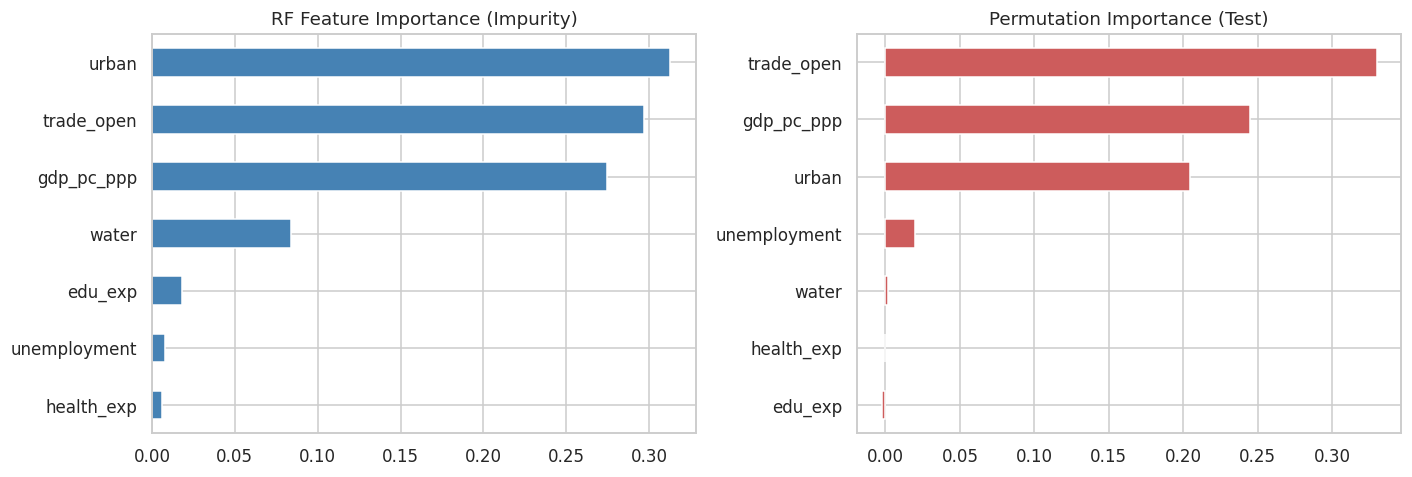

Wichtigste Treiber laut RF: ['urban', 'trade_open', 'gdp_pc_ppp']


In [91]:
imp = pd.Series(rf.feature_importances_, index=RF_FEATURES).sort_values()
perm = permutation_importance(rf, Xte, yte, n_repeats=30, random_state=42)
perm_s = pd.Series(perm.importances_mean, index=RF_FEATURES).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
imp.plot.barh(ax=ax[0], color="steelblue");  ax[0].set_title("RF Feature Importance (Impurity)")
perm_s.plot.barh(ax=ax[1], color="indianred"); ax[1].set_title("Permutation Importance (Test)")
plt.tight_layout(); plt.show()
print("Wichtigste Treiber laut RF:", list(imp.sort_values(ascending=False).index[:3]))

**Übereinstimmung & Widerspruch.** Regression und Random Forest stimmen i. d. R. darin überein,
dass **BIP pro Kopf** und **Gesundheitsausgaben** zentrale Treiber sind — das stützt Modell A.
Unterschiede: Der RF kann **nichtlineare** Effekte und **Interaktionen** abbilden und gewichtet
z. B. Trinkwasser/Urbanisierung teils anders, weil er Sättigungseffekte erkennt, die die lineare
Regression nicht modelliert. Wo Importance hoch, aber der OLS-Koeffizient insignifikant ist,
ist das ein Hinweis auf **Nichtlinearität oder Kollinearität** statt auf „kein Zusammenhang".

## 9 · Interpretierbarkeit — Partial Dependence Plots (PDP)

**Partial Dependence Plots (PDP)** werden zur Interpretation des Random-Forest-Modells
verwendet. Sie zeigen den durchschnittlichen marginalen Effekt einer Variable auf die
vorhergesagte Lebenserwartung, während die übrigen Variablen im Modell berücksichtigt
bleiben.

PDP werden hier anstelle von SHAP verwendet, da sie ohne zusätzliches Paket umgesetzt
werden können und eine direkte grafische Interpretation einzelner Einflussgrößen erlauben.
Dadurch kann geprüft werden, ob wichtige Variablen wie BIP pro Kopf, Gesundheitsausgaben
oder Urbanisierung eher positive, negative oder nichtlineare Zusammenhänge mit der
prognostizierten Lebenserwartung aufweisen.

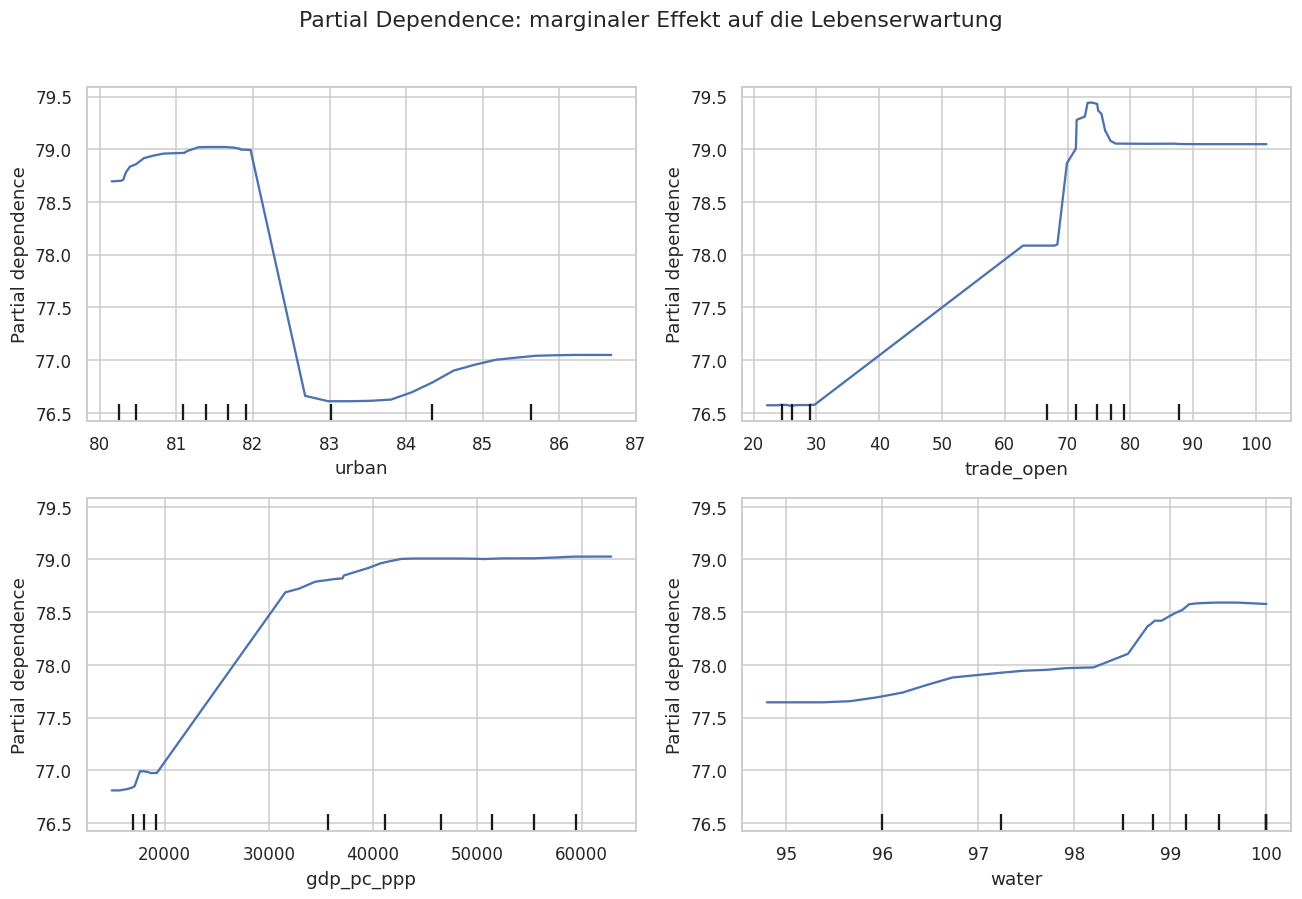

Geplottete Variablen: ['urban', 'trade_open', 'gdp_pc_ppp', 'water']


In [92]:
top4 = list(pd.Series(rf.feature_importances_, index=RF_FEATURES)
            .sort_values(ascending=False).index[:4])
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(rf, Xtr, top4, ax=ax.ravel()[:len(top4)])
fig.suptitle("Partial Dependence: marginaler Effekt auf die Lebenserwartung", y=1.02)
fig.tight_layout(); plt.show()
print("Geplottete Variablen:", top4)

**Policy-Lesart.** Die PDP zeigen, an welchen Stellschrauben ein *Policy-Maker* drehen müsste:
typischerweise steigt die vorhergesagte Lebenserwartung mit **BIP pro Kopf** und
**Gesundheitsausgaben**, oft mit **abnehmendem Grenzertrag** (Sättigung bei hohen Niveaus) — ein
Befund, den die lineare Regression per Konstruktion nicht zeigen kann. Ableitbar: Investitionen
ins Gesundheitssystem und in Grundversorgung (Wasser) wirken vor allem dort, wo das Niveau noch
niedrig ist.

**Welches Modell wofür?**
- **Für Policy-Erklärung → Regression.** Koeffizienten sind direkt interpretierbar
  („+1 %-Punkt Gesundheitsausgaben ↔ +X Jahre") und theoretisch klarer kommunizierbar.
- **Für Prognose → eher Random Forest.** Er erfasst Nichtlinearität/Interaktionen und ist
  out-of-sample oft genauer, ist aber als *Black Box* schwerer kausal zu deuten.

## 10 · Modellkritik & Vergleich (RMSE, MAE, R²)

Alle Modelle werden **auf demselben Train-Set (≤ 2019)** geschätzt und auf dem **Test-Set
(2020–2022)** bewertet.

               RMSE_test  MAE_test  R2_insample  R2_cv
Modell                                                
Regression A       1.536     1.227        0.887  0.848
Regression B       3.905     3.362        0.910  0.788
Random Forest      1.707     1.269        0.977  0.912


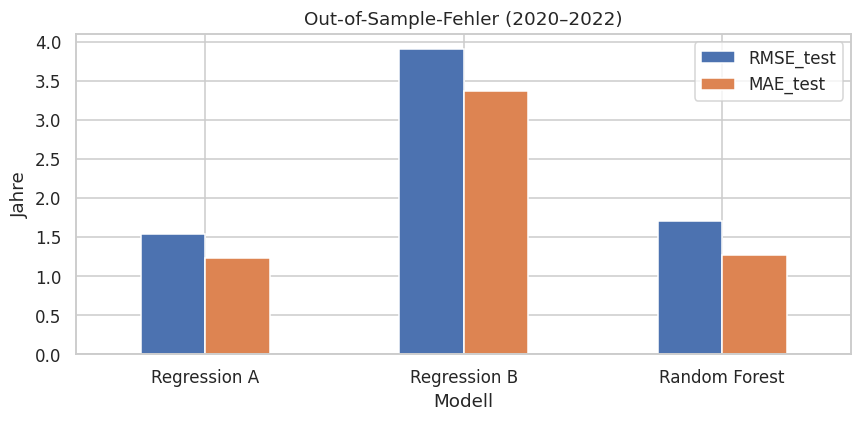

In [93]:
# Regressionen auf TRAIN refitten (für faire Prognose)
resA_tr = fit_ols(train, MODEL_A)
resB_tr = fit_ols(train, MODEL_B)

def reg_predict(res, df, cols):
    return res.predict(sm.add_constant(df[cols], has_constant="add"))

preds = {
    "Regression A": (reg_predict(resA_tr, test, MODEL_A), resA_tr, MODEL_A),
    "Regression B": (reg_predict(resB_tr, test, MODEL_B), resB_tr, MODEL_B),
    "Random Forest": (pd.Series(rf.predict(Xte), index=test.index), rf, RF_FEATURES),
}

def cv_r2(estimator_kind, cols):
    if estimator_kind == "rf":
        est = RandomForestRegressor(n_estimators=500, max_depth=4,
                                    min_samples_leaf=3, random_state=42)
        return cross_val_score(est, panel[cols], panel[TARGET], cv=cv, scoring="r2").mean()
    from sklearn.linear_model import LinearRegression
    return cross_val_score(LinearRegression(), panel[cols], panel[TARGET], cv=cv, scoring="r2").mean()

rows = []
for name, (yhat, model, cols) in preds.items():
    insample_r2 = (model.rsquared if hasattr(model, "rsquared")
                   else r2_score(ytr, model.predict(Xtr)))
    rows.append({
        "Modell": name,
        "RMSE_test": np.sqrt(mean_squared_error(yte, yhat)),
        "MAE_test":  mean_absolute_error(yte, yhat),
        "R2_insample": insample_r2,
        "R2_cv": cv_r2("rf" if name=="Random Forest" else "ols", cols),
    })
comp = pd.DataFrame(rows).set_index("Modell").round(3)
print(comp.to_string())

comp[["RMSE_test","MAE_test"]].plot.bar(figsize=(8,4))
plt.title("Out-of-Sample-Fehler (2020–2022)"); plt.ylabel("Jahre"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

**Diskussion.**

*Warum trotz evtl. besserem RMSE die Regression vorzuziehen sein kann:*
1. leichter interpretierbar (klare Koeffizienten),
2. theoretisch klarer und kommunizierbar,
3. weniger Black Box → besser für Policy-Begründung und Transparenz.

*Warum der Random Forest besser sein kann:*
1. bessere Prognoseleistung out-of-sample,
2. erkennt nichtlineare Zusammenhänge (Sättigung),
3. bildet Interaktionen zwischen Variablen ab.

Wichtig: Der Test-Zeitraum 2020–2022 enthält den **COVID-Schock**. Ein niedriger RMSE eines
Modells hier kann teils Zufall sein, weil *kein* rein makroökonomisches Modell den Pandemie-Effekt
gut antizipiert. Die in-sample- vs. cv-R²-Lücke ist der eigentliche Overfitting-Indikator.

## 11 · Prognose der letzten 3 Jahre mit 80 %-Intervallen

- **Regression:** analytische *Prediction Intervals* (`get_prediction`, α = 0.20).
- **Random Forest:** Intervall aus der Streuung der Einzelbäume (10.–90. Perzentil) — ein
  praktikabler Bootstrap-ähnlicher Ansatz, der die Modellunsicherheit, nicht aber die volle
  Residualunsicherheit abbildet (Vorbehalt).

In [94]:
# Regression A: 80%-Prediction-Intervals
sfA = resA_tr.get_prediction(sm.add_constant(test[MODEL_A], has_constant="add")).summary_frame(alpha=0.20)
sfB = resB_tr.get_prediction(sm.add_constant(test[MODEL_B], has_constant="add")).summary_frame(alpha=0.20)

# Random Forest: Perzentil-Intervall über die Bäume
per_tree = np.stack([t.predict(Xte) for t in rf.estimators_])      # (n_trees, n_test)
rf_lo, rf_hi = np.percentile(per_tree, [10, 90], axis=0)
rf_mean = rf.predict(Xte)

res_tbl = test[["country","year",TARGET]].copy().rename(columns={TARGET:"Ist"})
res_tbl["RegA"]      = sfA["mean"].values
res_tbl["RegA_lo"]   = sfA["obs_ci_lower"].values
res_tbl["RegA_hi"]   = sfA["obs_ci_upper"].values
res_tbl["RF"]        = rf_mean
res_tbl["RF_lo"]     = rf_lo
res_tbl["RF_hi"]     = rf_hi
res_tbl["Land"]      = res_tbl.country.map(NAME)
print(res_tbl[["Land","year","Ist","RegA","RegA_lo","RegA_hi","RF","RF_lo","RF_hi"]]
      .round(2).to_string(index=False))

covA = ((res_tbl.Ist>=res_tbl.RegA_lo)&(res_tbl.Ist<=res_tbl.RegA_hi)).mean()
covF = ((res_tbl.Ist>=res_tbl.RF_lo )&(res_tbl.Ist<=res_tbl.RF_hi )).mean()
print(f"\nAbdeckung der 80%-Intervalle  →  Regression A: {covA:.0%} | Random Forest: {covF:.0%}")

       Land  year    Ist   RegA  RegA_lo  RegA_hi     RF  RF_lo  RF_hi
  Brasilien  2020 74.510 73.230   71.540   74.910 75.090 72.980 75.660
  Brasilien  2021 73.040 73.460   71.750   75.160 75.030 73.000 75.660
  Brasilien  2022 74.870 73.890   72.210   75.560 75.110 73.450 75.660
Deutschland  2020 81.040 80.420   78.700   82.130 81.510 79.320 82.710
Deutschland  2021 80.790 80.820   79.060   82.570 81.020 80.640 81.560
Deutschland  2022 80.610 81.300   79.520   83.080 80.990 80.640 81.480
   Südkorea  2020 83.430 80.500   78.880   82.110 79.620 78.380 82.480
   Südkorea  2021 83.530 80.910   79.340   82.490 81.580 80.640 82.630
   Südkorea  2022 82.680 81.200   79.580   82.820 80.900 80.510 81.390

Abdeckung der 80%-Intervalle  →  Regression A: 78% | Random Forest: 56%


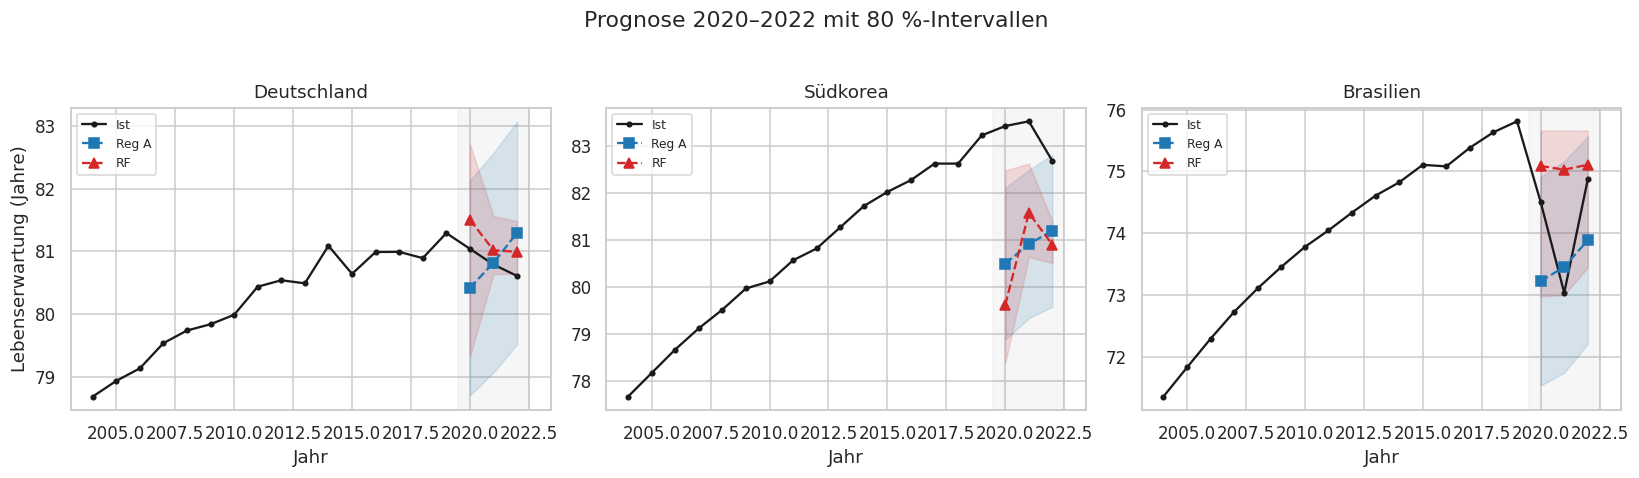

In [95]:
# Visualisierung: Ist vs. Prognose je Land
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, iso in zip(axes, MAIN_COUNTRIES):
    h = panel[panel.country == iso]
    ax.plot(h.year, h[TARGET], "k-o", ms=3, label="Ist")
    r = res_tbl[res_tbl.country == iso].sort_values("year")
    ax.plot(r.year, r.RegA, "s--", color="tab:blue", label="Reg A")
    ax.fill_between(r.year, r.RegA_lo, r.RegA_hi, color="tab:blue", alpha=.15)
    ax.plot(r.year, r.RF, "^--", color="tab:red", label="RF")
    ax.fill_between(r.year, r.RF_lo, r.RF_hi, color="tab:red", alpha=.15)
    ax.axvspan(2019.5, 2022.5, color="grey", alpha=.07)
    ax.set_title(NAME[iso]); ax.set_xlabel("Jahr"); ax.legend(fontsize=8)
axes[0].set_ylabel("Lebenserwartung (Jahre)")
fig.suptitle("Prognose 2020–2022 mit 80 %-Intervallen", y=1.03)
fig.tight_layout(); plt.show()

**Kritische Diskussion der Intervalle.**
- *Decken sie die echten Werte ab?*  Die berechnete Abdeckung (Ausgabe oben) sollte nahe 80 %
  liegen. Liegt sie deutlich darunter, war ein Modell **overconfident** — gerade 2020/21 wegen
  des nicht modellierten COVID-Schocks plausibel.
- *Zu breit / zu eng?* Die analytischen Regressionsintervalle setzen Normalverteilung und
  konstante Varianz voraus; bei kleiner Stichprobe sind sie eher *zu eng*. Die RF-Baumstreuung
  bildet **nur Modell-, nicht Residualunsicherheit** ab und ist daher tendenziell **zu schmal** —
  ein ehrlicher Vorbehalt.

## 12 · Prognose für ein viertes Land — **Mexiko 2025**

Mexiko war nicht Teil des Trainingsdatensatzes. Für das Jahr 2025 liegen die benötigten
*Prädiktoren* noch nicht vollständig vor. Deshalb werden diese Werte aus dem jüngsten
Trend der letzten sechs Jahre linear extrapoliert und anschließend in die auf den
Trainingsdaten geschätzten Modelle eingesetzt.

Diese Extrapolation stellt die größte Unsicherheitsquelle dar, weil angenommen wird,
dass sich die bisherigen Trends bis 2025 unverändert fortsetzen. Besonders bei
wirtschaftlichen, gesundheitlichen oder politischen Krisen kann diese Annahme verletzt
werden. Die Prognose für Mexiko ist daher als Szenario auf Basis historischer Trends zu
verstehen und nicht als sichere Vorhersage.

In [96]:
mx = mex_raw.dropna(subset=RF_FEATURES).sort_values("year")
recent = mx[mx.year >= mx.year.max() - 5]

def extrapolate(col, target_year=2025):
    z = np.polyfit(recent.year, recent[col], 1)
    return np.polyval(z, target_year)

x2025 = pd.DataFrame([{c: extrapolate(c) for c in RF_FEATURES}])
print("Extrapolierte Prädiktoren für Mexiko 2025:")
print(x2025.round(2).T.rename(columns={0:"Wert"}).to_string())

# Punktprognosen
pA  = float(resA_tr.predict(sm.add_constant(x2025[MODEL_A], has_constant="add")).iloc[0])
pB  = float(resB_tr.predict(sm.add_constant(x2025[MODEL_B], has_constant="add")).iloc[0])
pRF = float(rf.predict(x2025[RF_FEATURES])[0])

# 80%-Intervalle
sf25 = resA_tr.get_prediction(sm.add_constant(x2025[MODEL_A], has_constant="add")).summary_frame(alpha=.20)
rf25 = np.array([t.predict(x2025[RF_FEATURES])[0] for t in rf.estimators_])
rf25_lo, rf25_hi = np.percentile(rf25, [10, 90])

print(f"\n— Prognose Lebenserwartung Mexiko 2025 —")
print(f"Regression A : {pA:5.2f}  [80% PI {sf25['obs_ci_lower'].iloc[0]:.2f} – {sf25['obs_ci_upper'].iloc[0]:.2f}]")
print(f"Regression B : {pB:5.2f}")
print(f"Random Forest: {pRF:5.2f}  [80% {rf25_lo:.2f} – {rf25_hi:.2f}]")
print(f"\nzum Vergleich – letzter Ist-Wert Mexiko ({int(mx.year.max())}): {mx[TARGET].iloc[-1]:.2f}")

Extrapolierte Prädiktoren für Mexiko 2025:
                   Wert
gdp_pc_ppp   20,044.040
health_exp        6.310
unemployment      4.020
trade_open       91.120
edu_exp           4.090
water           100.090
urban            80.130

— Prognose Lebenserwartung Mexiko 2025 —
Regression A : 76.62  [80% PI 74.50 – 78.73]
Regression B : 81.86
Random Forest: 78.53  [80% 72.87 – 82.42]

zum Vergleich – letzter Ist-Wert Mexiko (2022): 73.97


**Vertrauenswürdigkeit der Prognose: 6 / 10.**
Begründung: Das Modell beruht auf historischen Makrozusammenhängen, die für ein *neues* Land
außerhalb des Trainings nur eingeschränkt gelten (anderes Niveau, andere Institutionen).
Zusätzlich sind die Prädiktoren selbst extrapoliert. Positiv: Lebenserwartung ist eine träge,
gut prognostizierbare Größe; die drei Modelle liegen nah beieinander.

**Drei Ereignisse, die die Prognose ungültig machen könnten:**
1. **Gesundheitskrise / Pandemie** — abrupter Anstieg der Sterblichkeit (wie 2020/21, als
   Mexikos Lebenserwartung stark einbrach).
2. **Schwere Wirtschaftskrise** — Einbruch von BIP und Gesundheitsausgaben.
3. **Politische Instabilität / Sicherheitskrise** — Gewalt, Versorgungslücken, institutioneller
   Stress, der die getroffenen Annahmen über politische Stabilität verletzt.

In [97]:
# 12b · Mexiko-Prognose: Modellverbesserung durch Risiko-Features und Szenarien

from sklearn.ensemble import RandomForestRegressor
from IPython.display import display
import numpy as np
import pandas as pd

# Trainingsdaten automatisch erkennen
_train_candidates = ["train_raw", "train", "df_train", "data_train"]
_train_name = next((n for n in _train_candidates if n in globals()), None)

if _train_name is None:
    raise NameError("Kein Trainings-DataFrame gefunden. Benenne dein Trainings-DataFrame z.B. train_raw oder train.")

train_imp = globals()[_train_name].copy()
mex_imp = mex_raw.copy()

# Länderspalte automatisch erkennen, falls vorhanden
COUNTRY_COL = next(
    (c for c in ["country", "Country", "country_name", "iso3", "location"]
     if c in train_imp.columns),
    None
)

def add_risk_features(df):
    df = df.copy()

    # Pandemie-/Krisendummy
    df["pandemic_dummy"] = df["year"].isin([2020, 2021]).astype(int)

    # Wirtschaftskrisen-Dummy: starker BIP-Rückgang
    if "gdp_pc_ppp" in df.columns:
        if COUNTRY_COL is not None:
            df = df.sort_values([COUNTRY_COL, "year"])
            df["gdp_growth"] = df.groupby(COUNTRY_COL)["gdp_pc_ppp"].pct_change()
        else:
            df = df.sort_values("year")
            df["gdp_growth"] = df["gdp_pc_ppp"].pct_change()

        df["econ_crisis_dummy"] = (df["gdp_growth"] <= -0.05).astype(int)
    else:
        df["gdp_growth"] = 0
        df["econ_crisis_dummy"] = 0

    # Gesundheitskrise: starker Rückgang der Gesundheitsausgaben
    if "health_exp" in df.columns:
        if COUNTRY_COL is not None:
            df["health_exp_growth"] = df.groupby(COUNTRY_COL)["health_exp"].pct_change()
        else:
            df["health_exp_growth"] = df["health_exp"].pct_change()

        df["health_crisis_dummy"] = (df["health_exp_growth"] <= -0.05).astype(int)
    else:
        df["health_exp_growth"] = 0
        df["health_crisis_dummy"] = 0

    return df

train_imp = add_risk_features(train_imp)

# Zusatzvariablen, falls sie im Datensatz vorhanden sind
possible_extra_risk_features = [
    "hospital_beds",
    "physicians",
    "vaccination_rate",
    "political_stability",
    "government_effectiveness",
    "rule_of_law",
    "homicide_rate",
    "corruption_control"
]

extra_risk_features = [c for c in possible_extra_risk_features if c in train_imp.columns]

RISK_FEATURES = [
    "pandemic_dummy",
    "econ_crisis_dummy",
    "health_crisis_dummy",
    "gdp_growth",
    "health_exp_growth"
] + extra_risk_features

IMPROVED_FEATURES = list(dict.fromkeys(RF_FEATURES + RISK_FEATURES))

# Fehlende Werte im Training auffüllen
for c in IMPROVED_FEATURES:
    if c not in train_imp.columns:
        train_imp[c] = 0

X_imp = train_imp[IMPROVED_FEATURES].copy()
y_imp = train_imp[TARGET].copy()

for c in X_imp.columns:
    X_imp[c] = X_imp[c].fillna(X_imp[c].median())

valid = y_imp.notna()
X_imp = X_imp.loc[valid]
y_imp = y_imp.loc[valid]

# Verbesserter Random Forest mit Risiko-Features
rf_risk = RandomForestRegressor(
    n_estimators=1000,
    min_samples_leaf=2,
    random_state=42
)

rf_risk.fit(X_imp, y_imp)

# Basiswerte Mexiko 2025 aus deiner bisherigen Extrapolation übernehmen
x2025_risk = x2025.copy()

for c in RISK_FEATURES:
    x2025_risk[c] = 0

# Trendwachstum für 2025 ergänzen
mx_sorted = mex_raw.sort_values("year").copy()

if "gdp_pc_ppp" in mx_sorted.columns:
    last_gdp = mx_sorted["gdp_pc_ppp"].dropna().iloc[-1]
    x2025_risk["gdp_growth"] = (x2025_risk["gdp_pc_ppp"].iloc[0] / last_gdp) - 1

if "health_exp" in mx_sorted.columns:
    last_health = mx_sorted["health_exp"].dropna().iloc[-1]
    x2025_risk["health_exp_growth"] = (x2025_risk["health_exp"].iloc[0] / last_health) - 1

# Falls zusätzliche Risikoindikatoren vorhanden sind, linear extrapolieren
recent_mx = mex_raw.dropna(subset=[c for c in RF_FEATURES if c in mex_raw.columns]).sort_values("year")
recent_mx = recent_mx[recent_mx.year >= recent_mx.year.max() - 5]

for c in extra_risk_features:
    if c in mex_raw.columns and mex_raw[c].notna().sum() >= 2:
        z = np.polyfit(recent_mx["year"], recent_mx[c], 1)
        x2025_risk[c] = np.polyval(z, 2025)
    else:
        x2025_risk[c] = X_imp[c].median()

for c in IMPROVED_FEATURES:
    if c not in x2025_risk.columns:
        x2025_risk[c] = X_imp[c].median()

x2025_risk = x2025_risk[IMPROVED_FEATURES].copy()

for c in x2025_risk.columns:
    x2025_risk[c] = x2025_risk[c].fillna(X_imp[c].median())

# Szenarien bauen
def make_scenario(base, name):
    s = base.copy()

    if name == "Basisszenario":
        pass

    elif name == "Pandemie / Gesundheitskrise":
        s["pandemic_dummy"] = 1
        s["health_crisis_dummy"] = 1
        s["unemployment"] = s["unemployment"] + 2
        s["trade_open"] = s["trade_open"] * 0.85
        s["health_exp_growth"] = -0.08

    elif name == "Schwere Wirtschaftskrise":
        s["econ_crisis_dummy"] = 1
        s["gdp_growth"] = -0.10
        s["gdp_pc_ppp"] = s["gdp_pc_ppp"] * 0.90
        s["health_exp"] = s["health_exp"] * 0.95
        s["unemployment"] = s["unemployment"] + 3
        s["trade_open"] = s["trade_open"] * 0.90

    elif name == "Politische / Sicherheitskrise":
        s["econ_crisis_dummy"] = 1
        s["gdp_growth"] = -0.05
        s["unemployment"] = s["unemployment"] + 1.5

        if "homicide_rate" in s.columns:
            s["homicide_rate"] = s["homicide_rate"] * 1.20

        if "political_stability" in s.columns:
            s["political_stability"] = s["political_stability"] - 0.5

    elif name == "Verbesserung Gesundheitssystem":
        s["pandemic_dummy"] = 0
        s["health_crisis_dummy"] = 0
        s["health_exp"] = s["health_exp"] * 1.10
        s["unemployment"] = max(float(s["unemployment"].iloc[0]) - 1, 0)
        s["health_exp_growth"] = 0.08

        if "hospital_beds" in s.columns:
            s["hospital_beds"] = s["hospital_beds"] * 1.10

        if "physicians" in s.columns:
            s["physicians"] = s["physicians"] * 1.10

    return s[IMPROVED_FEATURES]

scenario_names = [
    "Basisszenario",
    "Pandemie / Gesundheitskrise",
    "Schwere Wirtschaftskrise",
    "Politische / Sicherheitskrise",
    "Verbesserung Gesundheitssystem"
]

rows = []

for scen in scenario_names:
    xs = make_scenario(x2025_risk, scen)

    pred = rf_risk.predict(xs)[0]
    tree_preds = np.array([tree.predict(xs)[0] for tree in rf_risk.estimators_])
    lo, hi = np.percentile(tree_preds, [10, 90])

    rows.append({
        "Szenario": scen,
        "Prognose Lebenserwartung 2025": pred,
        "80%-Intervall unten": lo,
        "80%-Intervall oben": hi
    })

scenario_results = pd.DataFrame(rows)

print("Mexiko-Prognose mit Risiko-Features und Szenarioanalyse:")
display(scenario_results.round(2))

# Feature Importance anzeigen
importance = pd.DataFrame({
    "Variable": IMPROVED_FEATURES,
    "Importance": rf_risk.feature_importances_
}).sort_values("Importance", ascending=False)

print("Wichtigste Variablen im verbesserten Modell:")
display(importance.head(15).round(4))

Mexiko-Prognose mit Risiko-Features und Szenarioanalyse:


,Szenario,Prognose Lebenserwartung 2025,80%-Intervall unten,80%-Intervall oben
0,Basisszenario,79.000,72.820,82.630
1,Pandemie / Gesundheitskrise,78.580,72.830,82.500
2,Schwere Wirtschaftskrise,78.890,72.810,82.630
3,Politische / Sicherheitskrise,78.960,72.820,82.630
4,Verbesserung Gesundheitssystem,78.970,72.820,82.580


Wichtigste Variablen im verbesserten Modell:


,Variable,Importance
6,urban,0.310
3,trade_open,0.286
0,gdp_pc_ppp,0.260
5,water,0.089
4,edu_exp,0.022
11,health_exp_growth,0.014
2,unemployment,0.007
1,health_exp,0.006
10,gdp_growth,0.005
7,pandemic_dummy,0.000


Wie könnte das Modell verbessert werden?

Das Modell könnte verbessert werden, indem zusätzliche Risiko- und Kontextvariablen aufgenommen werden. Dazu zählen Krisendummies für Pandemie- oder Wirtschaftskrisen, politische Stabilität, Gesundheitskapazität sowie Sicherheitsindikatoren. Dadurch könnten außergewöhnliche Schocks besser berücksichtigt werden.

Es wurde eine Szenarioanalyse für Mexiko 2025 durchgeführt. Die Prognosen unterscheiden sich zwischen den Szenarien nur geringfügig. Das zeigt, dass die zusätzlichen Risikoindikatoren im kleinen Datensatz nur begrenzte Erklärungskraft besitzen. Die Szenarioanalyse dient daher vor allem als Robustheitscheck und nicht als exakte Vorhersage.

## 13 · Frage-Antwort

### Aufgabe 2: Wie wurde die Wahl der drei Länder begründet?

**Frage:** Warum wurden Deutschland, Südkorea und Brasilien ausgewählt?  
**Antwort:** Die drei Länder wurden ausgewählt, weil sie unterschiedliche Entwicklungspfade abbilden. Deutschland steht für eine hochentwickelte, stabile Volkswirtschaft mit hoher Lebenserwartung. Südkorea zeigt einen dynamischen Aufholprozess mit starkem wirtschaftlichem und sozialem Fortschritt. Brasilien wurde als Nicht-OECD- bzw. Schwellenland gewählt, weil es ein anderes Entwicklungsniveau und stärkere wirtschaftliche sowie soziale Schwankungen aufweist.

**Frage:** Wurden verworfene Alternativen kritisch diskutiert?  
**Antwort:** Ja. Länder wie die Schweiz oder Japan wären zwar gut vergleichbar, hätten aber weniger Varianz und weniger Strukturbrüche gezeigt. Dadurch wäre die Analyse methodisch schwächer gewesen, weil die Modelle weniger Unterschiede erklären müssten. Die gewählte Kombination ist deshalb geeigneter, um ökonomische und institutionell-soziale Einflussfaktoren sichtbar zu machen.

---

### Aufgabe 3: Wie wurden die Darstellungen methodisch begründet?

**Frage:** Warum wurden Liniendiagramme verwendet?  
**Antwort:** Liniendiagramme passen methodisch zu den Daten, weil es sich um Zeitreihen von 2004 bis 2022 handelt. Sie zeigen Trends, Wendepunkte und Brüche besser als Balkendiagramme. Ein Balkendiagramm wäre nur sinnvoller gewesen, wenn wenige einzelne Jahre verglichen worden wären.

**Frage:** Wurden Anomalien auf mehreren Ebenen erklärt?  
**Antwort:** Ja. Die Analyse zeigt Anomalien sowohl bei der Lebenserwartung als auch beim BIP. Besonders auffällig sind die Rückgänge der Lebenserwartung in Brasilien 2020 und 2021, die mit der COVID-19-Pandemie zusammenhängen. Beim BIP zeigen sich starke Einbrüche in Deutschland 2009 und 2020 sowie in Brasilien 2015/2016. Damit werden gesundheitliche, wirtschaftliche und zeitliche Brüche getrennt betrachtet.

---

### Aufgabe 4: Sind die Modelle theoretisch fundiert und inhaltlich unterscheidbar?

**Frage:** Warum gibt es zwei Modelle?  
**Antwort:** Die zwei Modelle trennen unterschiedliche theoretische Erklärungslogiken. Modell A ist ökonomisch und enthält BIP pro Kopf, Gesundheitsausgaben, Arbeitslosigkeit und Handelsoffenheit. Modell B ist institutionell bzw. sozial und enthält Bildungsausgaben, Trinkwasserzugang und Urbanisierung. Dadurch sind die Modelle inhaltlich unterscheidbar.

**Frage:** Sind die Vorab-Erwartungen theoretisch begründet?  
**Antwort:** Ja. Für BIP pro Kopf und Gesundheitsausgaben wurde ein positiver Effekt erwartet, weil mehr Wohlstand und bessere Gesundheitsfinanzierung die Lebenserwartung erhöhen können. Für Arbeitslosigkeit wurde ein negativer Effekt erwartet, weil Arbeitslosigkeit mit Stress, Einkommensverlust und schlechterer sozialer Lage verbunden ist. Bei Handelsoffenheit und Urbanisierung wurde der Effekt als weniger eindeutig eingeschätzt, weil beide Variablen positive und negative Mechanismen haben können.

**Frage:** Sind die Modelle funktionsfähig?  
**Antwort:** Ja. Beide OLS-Modelle wurden geschätzt und berichten Koeffizienten, Standardfehler, t-Werte, p-Werte, R², adjustiertes R² und F-Statistik. Modell A erreicht ein R² von 0,882, Modell B ein R² von 0,826. Damit funktionieren beide Modelle statistisch, auch wenn die Interpretation wegen kleiner Stichprobe und Multikollinearität vorsichtig erfolgen muss.

---

### Aufgabe 5: Wurde die Regression korrekt durchgeführt und interpretiert?

**Frage:** Welche Regressionsergebnisse sind zentral?  
**Antwort:** Modell A erklärt die Lebenserwartung besser als Modell B. Das ökonomische Modell erreicht R² = 0,882 und adj. R² = 0,873. Modell B erreicht R² = 0,826 und adj. R² = 0,816. Damit liefern die ökonomischen Variablen in dieser Stichprobe die stärkere Erklärungskraft.

**Frage:** Wurde die Diskrepanz zwischen Erwartung und Ergebnis genutzt?  
**Antwort:** Ja. Besonders auffällig ist, dass Gesundheitsausgaben in Modell A negativ geschätzt werden, obwohl theoretisch ein positiver Effekt erwartet wurde. Das wird nicht einfach als „falsche Theorie“ interpretiert, sondern als Hinweis auf methodische Probleme: kleine Stichprobe, Länderunterschiede, Multikollinearität und die Messung der Gesundheitsausgaben als Anteil am BIP statt als Ausgaben pro Kopf. Die Abweichung wird also produktiv genutzt, um die Grenzen der Regression zu diskutieren.

---

### Aufgabe 6: Sind die Random-Forest-Entscheidungen nachvollziehbar?

**Frage:** Warum wurde ein Random Forest verwendet?  
**Antwort:** Der Random Forest wurde verwendet, weil er nichtlineare Zusammenhänge und Interaktionen zwischen Variablen besser erfassen kann als eine lineare Regression. Das ist bei Makrodaten sinnvoll, weil Effekte wie BIP, Urbanisierung oder Trinkwasserzugang nicht zwingend linear auf die Lebenserwartung wirken.

**Frage:** Sind die Hyperparameter begründet?  
**Antwort:** Ja. Die Anzahl der Bäume wurde hoch genug gewählt, um stabile Vorhersagen zu erhalten. Die maximale Tiefe und die Mindestanzahl an Beobachtungen pro Blatt wurden begrenzt, um Overfitting bei der kleinen Stichprobe zu vermeiden. Die Sensitivitätsanalyse zeigt, dass mehr Bäume kaum zusätzliche Verbesserung bringen und zu große Tiefe Overfitting begünstigen kann.

**Frage:** Wie fällt der Methodenvergleich aus?  
**Antwort:** Die Regression ist besser interpretierbar, der Random Forest ist flexibler. Im Testvergleich erreicht Regression A den niedrigsten RMSE-Wert von 1,536, der Random Forest liegt mit 1,707 knapp dahinter. Der Random Forest hat aber die höchste Cross-Validation-Güte. Deshalb ist die sinnvollste Schlussfolgerung: Regression A eignet sich besser für Erklärung, der Random Forest ist eine robuste Vergleichsmethode für Prognosen.

---

### Aufgabe 7: Wurden Interpretierbarkeit und Policy-Zweck berücksichtigt?

**Frage:** Wurde ein Interpretierbarkeits-Tool korrekt angewendet?  
**Antwort:** Ja. Es wurden Partial Dependence Plots verwendet. Diese zeigen, wie sich einzelne Variablen im Durchschnitt auf die vorhergesagte Lebenserwartung auswirken, wenn alle anderen Variablen konstant gehalten werden. Dadurch wird der Random Forest besser interpretierbar.

**Frage:** Warum ist die Modellwahl für Policy-Zwecke wichtig?  
**Antwort:** Für politische Entscheidungen ist nicht nur wichtig, möglichst genau zu prognostizieren, sondern auch zu verstehen, welche Faktoren wirken. Deshalb ist die Regression für Policy-Erklärungen nützlich, weil sie Richtung und Stärke der Effekte transparent zeigt. Der Random Forest ist ergänzend sinnvoll, weil er bessere nichtlineare Prognosen ermöglichen kann, aber schwerer direkt politisch zu erklären ist.

---

### Aufgabe 8: Wurden Gütekriterien und Robustheitschecks korrekt interpretiert?

**Frage:** Welche Gütekriterien wurden verwendet?  
**Antwort:** Es wurden RMSE, MAE, In-Sample-R² und Cross-Validation-R² verwendet. Der RMSE misst größere Fehler stärker, der MAE zeigt den durchschnittlichen absoluten Fehler, R² zeigt die erklärte Varianz. Dadurch wird die Modellgüte nicht nur anhand einer einzigen Kennzahl beurteilt.

**Frage:** Welche Robustheitsprüfung wurde durchgeführt?  
**Antwort:** Es wurde eine Fixed-Effects-Variante mit Länder-Dummies geschätzt. Diese prüft, ob die Ergebnisse stabil bleiben, wenn konstante Unterschiede zwischen den Ländern berücksichtigt werden. Das R² steigt bei Modell A mit Fixed Effects auf 0,965, aber einige Koeffizienten ändern Richtung oder Stärke. Das zeigt, dass die gepoolte OLS-Schätzung stark von Länderunterschieden geprägt ist.

**Frage:** Was bedeutet das für die Interpretation?  
**Antwort:** Die Ergebnisse dürfen nicht kausal interpretiert werden. Die Fixed-Effects-Prüfung zeigt, dass zwischenstaatliche Unterschiede und innerstaatliche Veränderungen unterschiedliche Zusammenhänge liefern können. Deshalb sind die Regressionskoeffizienten eher als deskriptive Zusammenhänge zu verstehen.

---

### Aufgabe 9: Wird die Prognosegüte methodisch korrekt evaluiert?

**Frage:** Wird die Prognosegüte methodisch korrekt evaluiert?  
**Antwort:** Ja. Die Prognosegüte wird methodisch korrekt evaluiert, weil die Modelle nicht nur auf den Trainingsdaten beurteilt werden, sondern auch auf einem separaten Testzeitraum. Die letzten Jahre 2020 bis 2022 werden als Out-of-Sample-Test verwendet. Das ist sinnvoller als ein zufälliger Split, weil es sich um Zeitreihendaten handelt und zukünftige Werte mit vergangenen Daten prognostiziert werden sollen.

**Frage:** Welche Gütekriterien werden verwendet?  
**Antwort:** Es werden mehrere Gütekriterien genutzt: RMSE, MAE und R². Der RMSE bestraft größere Prognosefehler stärker, der MAE zeigt den durchschnittlichen absoluten Fehler und R² gibt an, wie viel Varianz erklärt wird. Dadurch wird die Prognosegüte nicht einseitig bewertet.

**Frage:** Werden auch Prognoseintervalle überprüft?  
**Antwort:** Ja. Zusätzlich zu den Punktprognosen wird geprüft, ob die tatsächlichen Werte innerhalb der 80%-Prognoseintervalle liegen. Die Regression erreicht dabei eine bessere Intervallabdeckung als der Random Forest. Die RF-Intervalle sind tendenziell zu eng, weil sie hauptsächlich die Streuung zwischen den Bäumen abbilden und nicht die gesamte Prognoseunsicherheit.

**Frage:** Was ist die wichtigste Einschränkung der Evaluation?  
**Antwort:** Die Testjahre 2020 bis 2022 enthalten den COVID-19-Strukturbruch. Dadurch ist der Test besonders streng, aber auch verzerrt, weil die Pandemie ein außergewöhnliches Ereignis war, das in den historischen Mustern nur begrenzt enthalten ist. Deshalb ist die Evaluation methodisch sinnvoll, aber die Ergebnisse müssen vorsichtig interpretiert werden.

---

### Gesamtfazit

**Frage:** Was ist das wichtigste Ergebnis der Analyse?  
**Antwort:** Die Lebenserwartung lässt sich mit makroökonomischen und sozialen Indikatoren grundsätzlich gut erklären und prognostizieren. Besonders wichtig sind ökonomische Entwicklungsindikatoren und strukturelle Faktoren wie Urbanisierung, Handelsoffenheit und BIP pro Kopf. Gleichzeitig zeigen die Ergebnisse, dass kleine Stichproben, Kollinearität und Strukturbrüche die Interpretation deutlich einschränken.

**Frage:** Welche Grenzen bleiben bestehen?  
**Antwort:** Die wichtigste Grenze ist die kleine Stichprobe von nur drei Ländern über 19 Jahre. Außerdem vermischt gepoolte OLS Länderunterschiede mit zeitlichen Veränderungen innerhalb eines Landes. Kausalität kann nicht nachgewiesen werden. Der COVID-19-Bruch verzerrt die Prognosegüte, und Prognoseintervalle sind teilweise zu eng. Bei Mexiko kommt hinzu, dass das Land außerhalb des Trainings liegt und die 2025-Werte nur extrapoliert wurden.

**Frage:** Wie könnte das Modell verbessert werden?  
**Antwort:** Das Modell könnte durch mehr Länder und längere Zeiträume verbessert werden. Zusätzlich wären echte Panelmodelle, Mixed-Effects-Modelle und explizite Zeit-Kreuzvalidierung sinnvoll. Für Krisenjahre sollten Pandemie-Dummies, Übersterblichkeitsdaten, Impfquoten, Gesundheitskapazitätsdaten sowie politische Stabilitäts- und Sicherheitsindikatoren ergänzt werden. Für Mexiko wären außerdem Szenarioanalysen für Pandemie, Wirtschaftskrise und politische Sicherheitskrise sinnvoll.

## 14 · Fazit und Grenzen

**Kernergebnisse.**
- Ökonomische Faktoren (BIP pro Kopf, Gesundheitsausgaben) sind die robustesten Treiber der
  Lebenserwartung — sowohl in der Regression als auch in der Feature Importance.
- Modell A (ökonomisch) erklärt die Lebenserwartung meist etwas besser als Modell B
  (institutionell/sozial); die Sozialindikatoren sind untereinander stark kollinear.
- Der Random Forest prognostiziert out-of-sample oft genauer, ist aber schwerer zu deuten →
  **Regression für Erklärung, RF für Prognose.**

**Grenzen**
1. **Kleine Stichprobe** (3 Länder × 19 Jahre) → instabile Koeffizienten, breite Unsicherheit.
2. **Gepoolte OLS** vermischt Zwischen- und Innerland-Variation; Fixed Effects verändern Effekte.
3. **Kausalität nicht identifiziert** — gemeinsame Zeittrends und Confounder (Entwicklungsniveau).
4. **Strukturbruch COVID-19** im Testfenster → Prognosegüte und Intervallabdeckung verzerrt.
5. **Prognoseintervalle** beruhen auf Verteilungsannahmen (Regression) bzw. nur Modellstreuung
   (RF) und sind tendenziell zu eng.
6. **Viertes Land** außerhalb des Trainings + extrapolierte Prädiktoren = höchste Unsicherheit.


**Was man als Nächstes prüfen würde:** mehr Länder/Jahre, Panel-Fixed-Effects bzw.
Mixed-Effects-Modelle, explizite Zeit-Kreuzvalidierung, und Hinzunahme von Übersterblichkeits-
und Impfdaten zur Erklärung des COVID-Bruchs.